# Food Safety Detection: MiniLM + DeBERTa Pipeline

Detects food safety complaints in Amazon reviews using a simple two-stage NLP pipeline.  
**No keyword lists, no regex** — purely semantic similarity.

| Stage | Model | Job |
|-------|-------|-----|
| 1 | `all-MiniLM-L6-v2` | Cast a wide net — find reviews semantically similar to known safety complaints |
| 2 | `cross-encoder/nli-deberta-v3-small` | Precision filter — remove false positives from Stage 1 |

**Post-processing:** Late weighting penalises 4–5★ reviews to further suppress false positives.

---
## 1. Setup

In [97]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient, UpdateOne
from tqdm import tqdm
import torch

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [98]:
# Connect to MongoDB
# Make sure mongod is running before executing this cell
CLIENT = MongoClient('mongodb://localhost:27017/')
DB     = CLIENT['amazon_reviews']
COL    = DB['reviews']

print('Connected to MongoDB.')
print(f'Documents in collection: {COL.count_documents({}):,}')

Connected to MongoDB.
Documents in collection: 568,454


In [99]:
# Load the CSV into MongoDB — skipped automatically if collection already has data
CSV_PATH = 'Reviews_withURL.csv'

if COL.count_documents({}) == 0:
    print('Importing CSV...')
    df_import = pd.read_csv(CSV_PATH, index_col=0)
    df_import = df_import.dropna(subset=['Text', 'Score'])

    for col in ['Id', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time']:
        df_import[col] = pd.to_numeric(df_import[col], errors='coerce')
    df_import = df_import.dropna(subset=['Id'])

    records = df_import.to_dict(orient='records')
    BATCH   = 10_000
    for i in range(0, len(records), BATCH):
        COL.insert_many(records[i:i+BATCH])
        print(f'  Inserted {min(i+BATCH, len(records)):,}/{len(records):,}', end='\r')

    print(f'\nDone. Total: {COL.count_documents({}):,}')
else:
    print(f'Collection already has {COL.count_documents({}):,} documents. Skipping.')

Collection already has 568,454 documents. Skipping.


---
## 2. Stage 1 — MiniLM Semantic Search

MiniLM converts each review into a vector and measures how similar it is to a set of **safety probe sentences**.  
Reviews above the similarity threshold are passed to Stage 2.

**Why deduplicate?**  
Amazon reviews can appear under multiple products (same text, different `ProductId`).  
We encode each unique text **once** and fan the score out to all matching documents — ~30% fewer GPU passes.

In [100]:
import pickle
from sentence_transformers import SentenceTransformer, util

# ── Cache settings ────────────────────────────────────────────────────
# Results are saved here after the first run.
# Delete the file to force a full re-run, otherwise the cached version is used.
CACHE_DIR     = 'cache'
CACHE_MINILM  = os.path.join(CACHE_DIR, 'stage1_minilm.pkl')   # MiniLM Stage 1 results
CACHE_DEBERTA = os.path.join(CACHE_DIR, 'stage2_deberta.pkl')  # DeBERTa Stage 2 results
os.makedirs(CACHE_DIR, exist_ok=True)

print(f'Cache folder : {os.path.abspath(CACHE_DIR)}')
print(f'  stage1_minilm.pkl  : {"EXISTS — will skip MiniLM encoding" if os.path.exists(CACHE_MINILM)  else "not found — will run MiniLM"}')
print(f'  stage2_deberta.pkl : {"EXISTS — will skip DeBERTa inference" if os.path.exists(CACHE_DEBERTA) else "not found — will run DeBERTa"}')

# ── Settings ─────────────────────────────────────────────────────────
SEMANTIC_THRESHOLD = 0.39
ENCODE_BATCH_SIZE  = 256
MAX_CHARS          = 384

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Only load the model if we actually need to run encoding
if os.path.exists(CACHE_MINILM):
    print(f'\nMiniLM model load skipped (cache exists).')
    model            = None
    probe_embeddings = None
else:
    print(f'\nLoading MiniLM on {device.upper()}...')
    model = SentenceTransformer('all-MiniLM-L6-v2', device=device)

    SAFETY_PROBES = [
        # Illness
        'Contracted severe food poisoning and vomiting',
        'Diagnosed with salmonella gastroenteritis infection',
        'Intense nausea and violent diarrhea all night',
        # Contamination
        'Disgusting maggots and worms crawling inside',
        'Sharp glass shards and hard plastic pieces hidden',
        'Tasted like toxic chemical bleach and soap',
        # Spoilage
        'Smells completely rancid, rotten, and putrid',
        'Covered in fuzzy green mold and fungus',
        'The can was bulging, bloated, and leaking',
        # Allergen
        'Anaphylactic shock, throat swelling, and breathing difficulty',
        'Severe allergic reaction and skin hives breakout',
        'Dangerous undisclosed hidden allergens ingredients',
        # Quality defect
        'Chipped my tooth on a hard dangerous object',
        'Tampered broken safety seal risk',
    ]
    probe_embeddings = model.encode(SAFETY_PROBES, convert_to_tensor=True, show_progress_bar=False)
    print(f'Model ready. {len(SAFETY_PROBES)} safety probes encoded.')

print(f'Similarity threshold: {SEMANTIC_THRESHOLD}')

Cache folder : c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\cache
  stage1_minilm.pkl  : EXISTS — will skip MiniLM encoding
  stage2_deberta.pkl : EXISTS — will skip DeBERTa inference

MiniLM model load skipped (cache exists).
Similarity threshold: 0.39


In [101]:
from collections import defaultdict

# Build a map: unique text → list of MongoDB _ids that share that exact text.
# This way we encode each unique review only once.
print('Building deduplication map...')
text_to_ids = defaultdict(list)

for doc in COL.find({'Text': {'$exists': True, '$ne': ''}}, {'_id': 1, 'Text': 1}):
    text_to_ids[str(doc['Text'])].append(doc['_id'])

unique_texts = list(text_to_ids.keys())
total_docs   = sum(len(v) for v in text_to_ids.values())

print(f'Total documents : {total_docs:,}')
print(f'Unique texts    : {len(unique_texts):,}')
print(f'Duplicates skip : {total_docs - len(unique_texts):,}  (no re-encoding needed)')

Building deduplication map...
Total documents : 568,454
Unique texts    : 393,579
Duplicates skip : 174,875  (no re-encoding needed)


In [102]:
if os.path.exists(CACHE_MINILM):
    print(f'Cache found: {CACHE_MINILM}')
    print('Skipping MiniLM encoding. Delete the file to re-run.')
else:
    # Encode every unique text and write the similarity score back to MongoDB.
    # Each score is fanned out to all _ids that share the same text.
    COL.create_index([('SemanticScore', 1)], sparse=True, background=True)

    batch_texts = []
    batch_keys  = []

    with tqdm(total=len(unique_texts), desc='MiniLM encoding', unit='texts') as pbar:
        for text in unique_texts:
            batch_texts.append(text[:MAX_CHARS])
            batch_keys.append(text)

            if len(batch_texts) == ENCODE_BATCH_SIZE:
                embeddings = model.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
                scores     = util.cos_sim(embeddings, probe_embeddings).max(dim=1).values.cpu().numpy()

                ops = []
                for key, score in zip(batch_keys, scores):
                    for doc_id in text_to_ids[key]:
                        ops.append(UpdateOne(
                            {'_id': doc_id},
                            {'$set': {
                                'SemanticScore':   float(score),
                                'SemanticFlagged': float(score) >= SEMANTIC_THRESHOLD,
                            }}
                        ))
                COL.bulk_write(ops, ordered=False)

                batch_texts = []
                batch_keys  = []
                pbar.update(ENCODE_BATCH_SIZE)

        # Flush the last partial batch
        if batch_texts:
            embeddings = model.encode(batch_texts, convert_to_tensor=True, show_progress_bar=False)
            scores     = util.cos_sim(embeddings, probe_embeddings).max(dim=1).values.cpu().numpy()
            ops = []
            for key, score in zip(batch_keys, scores):
                for doc_id in text_to_ids[key]:
                    ops.append(UpdateOne(
                        {'_id': doc_id},
                        {'$set': {
                            'SemanticScore':   float(score),
                            'SemanticFlagged': float(score) >= SEMANTIC_THRESHOLD,
                        }}
                    ))
            COL.bulk_write(ops, ordered=False)
            pbar.update(len(batch_texts))

    print('Encoding complete. Scores saved to MongoDB.')

Cache found: cache\stage1_minilm.pkl
Skipping MiniLM encoding. Delete the file to re-run.


In [103]:
if os.path.exists(CACHE_MINILM):
    print(f'Loading Stage 1 results from cache: {CACHE_MINILM}')
    with open(CACHE_MINILM, 'rb') as f:
        df = pickle.load(f)
    print(f'Loaded {len(df):,} rows from cache.')
else:
    print('Loading Stage 1 results from MongoDB...')
    cursor = COL.find(
        {'SemanticScore': {'$exists': True}},
        {'_id': 1, 'Score': 1, 'SemanticScore': 1, 'SemanticFlagged': 1}
    )
    df = pd.DataFrame(list(cursor))
    df['SemanticFlagged'] = df['SemanticFlagged'].fillna(False).astype(bool)

    print(f'Saving Stage 1 cache...')
    with open(CACHE_MINILM, 'wb') as f:
        pickle.dump(df, f)
    print(f'Cache saved: {CACHE_MINILM}')

df['SemanticFlagged'] = df['SemanticFlagged'].fillna(False).astype(bool)
total   = len(df)
flagged = int(df['SemanticFlagged'].sum())

print(f'\nTotal reviews  : {total:,}')
print(f'MiniLM flagged : {flagged:,}  ({flagged / total:.2%})')
print(f'Not flagged    : {total - flagged:,}')
print('\nStage 1 done. Proceed to DeBERTa.')

Loading Stage 1 results from cache: cache\stage1_minilm.pkl
Loaded 568,454 rows from cache.

Total reviews  : 568,454
MiniLM flagged : 23,587  (4.15%)
Not flagged    : 544,867

Stage 1 done. Proceed to DeBERTa.


---
## 3. Stage 2 — DeBERTa Precision Filter

MiniLM casts a wide net — some false positives slip through (e.g. *"This tea cured my nausea!"*).  
DeBERTa re-reads only the MiniLM candidates (~3–10% of the dataset) and classifies them into one of six labels.
Reviews classified as **`Safe`** are discarded (score set to 0.0).

| Label | Meaning |
|-------|---------|
| `Safe` | Customer used health language positively — not a hazard |
| `Illness` | Food poisoning, nausea, vomiting, infection |
| `Contamination` | Mold, insects, foreign objects |
| `Spoilage` | Expired, rotten, rancid |
| `Allergen` | Allergic reaction, undisclosed allergens |
| `Quality_Defect` | Broken packaging, undercooked food |

In [104]:
from transformers import pipeline as hf_pipeline

# ── These label definitions are always needed (cache or not) ──────────
SAFETY_LABELS = [
    'is safe and helped the consumer recover from previous health issues',
    'caused severe illness, food poisoning, or sickness',
    'contained physical contamination, mold, insects, or foreign objects',
    'was spoiled, expired, rotten, or smelled bad',
    'triggered a severe allergic reaction or contained undisclosed allergens',
    'had packaging defects, broken glass, or undercooked food',
]

LABEL_TO_CATEGORY = {
    'is safe and helped the consumer recover from previous health issues': 'Safe',
    'caused severe illness, food poisoning, or sickness':                  'Illness',
    'contained physical contamination, mold, insects, or foreign objects': 'Contamination',
    'was spoiled, expired, rotten, or smelled bad':                        'Spoilage',
    'triggered a severe allergic reaction or contained undisclosed allergens': 'Allergen',
    'had packaging defects, broken glass, or undercooked food':            'Quality_Defect',
}

SEVERITY_MAP = {
    'Illness':        'High',
    'Contamination':  'High',
    'Allergen':       'High',
    'Spoilage':       'Medium',
    'Quality_Defect': 'Low',
}

if os.path.exists(CACHE_DEBERTA):
    print(f'DeBERTa cache found: {CACHE_DEBERTA}')
    print('Loading candidates from cache — model will not be loaded.')
    with open(CACHE_DEBERTA, 'rb') as f:
        candidates = pickle.load(f)
    print(f'Loaded {len(candidates):,} candidates from cache.')
    deberta = None  # not needed
else:
    # ── Get MiniLM candidates and fetch their text from MongoDB ──────
    candidates = df[df['SemanticFlagged']].copy().reset_index(drop=True)

    print(f'Fetching text for {len(candidates):,} candidates from MongoDB...')
    cand_ids = candidates['_id'].tolist()
    text_map = {d['_id']: d.get('Text', '') for d in COL.find({'_id': {'$in': cand_ids}}, {'Text': 1})}
    candidates['Text'] = candidates['_id'].map(text_map).fillna('')
    print(f'Text loaded for {candidates["Text"].ne("").sum():,} candidates.\n')

    # ── Load DeBERTa model ────────────────────────────────────────────
    device_id = 0 if torch.cuda.is_available() else -1
    print('Loading DeBERTa model (cross-encoder/nli-deberta-v3-small)...')
    deberta = hf_pipeline(
        'zero-shot-classification',
        model='cross-encoder/nli-deberta-v3-small',
        device=device_id,
    )
    print(f'Model ready. Will run on {len(candidates):,} candidates.')

DeBERTa cache found: cache\stage2_deberta.pkl
Loading candidates from cache — model will not be loaded.
Loaded 23,587 candidates from cache.


In [105]:
DEBERTA_THRESHOLD = 0.50
MAX_CHARS_DEB     = 256
DEBERTA_BATCH     = 16

if os.path.exists(CACHE_DEBERTA):
    print(f'Using cached DeBERTa results. Skipping inference.')
else:
    texts      = candidates['Text'].str[:MAX_CHARS_DEB].tolist()
    scores_out = []
    cats_out   = []
    sevs_out   = []

    for i in tqdm(range(0, len(texts), DEBERTA_BATCH), desc='DeBERTa inference'):
        batch   = texts[i:i+DEBERTA_BATCH]
        results = deberta(
            batch,
            candidate_labels=SAFETY_LABELS,
            hypothesis_template='This review describes a product that {}.'
        )
        for res in results:
            top_label = res['labels'][0]
            top_score = res['scores'][0]
            category  = LABEL_TO_CATEGORY[top_label]

            if category == 'Safe':
                scores_out.append(0.0)
                cats_out.append('Safe')
                sevs_out.append('None')
            else:
                scores_out.append(top_score)
                cats_out.append(category)
                sevs_out.append(SEVERITY_MAP.get(category, 'Unknown'))

    candidates['DebertaScore']     = scores_out
    candidates['Category']         = cats_out
    candidates['Severity']         = sevs_out
    candidates['DebertaConfirmed'] = candidates['DebertaScore'] >= DEBERTA_THRESHOLD

    # Save cache so the next run can skip inference entirely
    print(f'Saving DeBERTa cache...')
    with open(CACHE_DEBERTA, 'wb') as f:
        pickle.dump(candidates, f)
    print(f'Cache saved: {CACHE_DEBERTA}')

confirmed = candidates[candidates['DebertaConfirmed']].copy()
false_pos = len(candidates) - len(confirmed)

print(f'\nStage 1  (MiniLM  >= {SEMANTIC_THRESHOLD}) : {len(candidates):,}')
print(f'Stage 2  (DeBERTa >= {DEBERTA_THRESHOLD}) : {len(confirmed):,}')
print(f'False positives removed          : {false_pos:,}  ({false_pos / max(len(candidates), 1):.1%})')

Using cached DeBERTa results. Skipping inference.

Stage 1  (MiniLM  >= 0.39) : 23,587
Stage 2  (DeBERTa >= 0.5) : 4,878
False positives removed          : 18,709  (79.3%)


---
## 4. Late Weighting

DeBERTa detects hazard language but cannot determine *direction* —  
a 5-star review saying *"cured my nausea"* scores similarly to a 1-star *"caused nausea"*.

Fix: multiply the DeBERTa score by a penalty based on the star rating **after** inference.

| Stars | Weight | Reason |
|:-----:|:------:|--------|
| 1–2 | 1.0 | Genuine complaint — keep raw score |
| 3   | 0.8 | Neutral — slight downward adjustment |
| 4–5 | 0.1 | Heavy penalty — satisfied customers are not safety victims |

In [106]:
def get_weight(star_rating):
    if star_rating in (1, 2):
        return 1.0
    elif star_rating == 3:
        return 0.8
    else:            # 4 or 5 stars
        return 0.1

confirmed = confirmed.copy()
confirmed['Weight']           = confirmed['Score'].apply(get_weight)
confirmed['FinalSafetyScore'] = (confirmed['DebertaScore'] * confirmed['Weight']).round(4)

print('=== FinalSafetyScore After Weighting ===')
print(confirmed['FinalSafetyScore'].describe().round(4).to_string())

before = int((confirmed['DebertaScore']     >= 0.85).sum())
after  = int((confirmed['FinalSafetyScore'] >= 0.85).sum())
print(f'\nDebertaScore     >= 0.85 : {before:,}')
print(f'FinalSafetyScore >= 0.85 : {after:,}')
print(f'Suppressed by weighting  : {before - after:,}')


=== FinalSafetyScore After Weighting ===
count    4878.0000
mean        0.4327
std         0.3099
min         0.0500
25%         0.0674
50%         0.5240
75%         0.6662
max         0.9973

DebertaScore     >= 0.85 : 694
FinalSafetyScore >= 0.85 : 444
Suppressed by weighting  : 250


---
## 5. Results & Export

In [107]:
n_total     = len(df)
n_minilm    = int(df['SemanticFlagged'].sum())
n_confirmed = len(confirmed)

print('=== Two-Stage Pipeline — Final Summary ===')
print(f'  Total reviews analysed     : {n_total:,}')
print(f'  Stage 1  MiniLM flagged    : {n_minilm:,}  ({n_minilm / n_total:.2%})')
print(f'  Stage 2  DeBERTa confirmed : {n_confirmed:,}  ({n_confirmed / n_total:.2%})')

print('\n=== Confirmed Reviews by Category ===')
print(confirmed[confirmed['Category'] != 'Safe']['Category'].value_counts().to_string())

print('\n=== Top 5 Highest-Risk Reviews ===')
top5 = confirmed.sort_values('FinalSafetyScore', ascending=False).head(5)
for _, row in top5.iterrows():
    print(f"  {row['Score']}* | {row['Category']} | DeBERTa: {row['DebertaScore']:.3f} | Weight: {row['Weight']} | Final: {row['FinalSafetyScore']:.3f}")
    print(f"  {str(row['Text'])[:250]}...")
    print('  ' + '-' * 68)


=== Two-Stage Pipeline — Final Summary ===
  Total reviews analysed     : 568,454
  Stage 1  MiniLM flagged    : 23,587  (4.15%)
  Stage 2  DeBERTa confirmed : 4,878  (0.86%)

=== Confirmed Reviews by Category ===
Category
Contamination     2578
Spoilage          1060
Illness            730
Quality_Defect     329
Allergen           181

=== Top 5 Highest-Risk Reviews ===
  1* | Contamination | DeBERTa: 0.997 | Weight: 1.0 | Final: 0.997
  I was so looking forward to these mushrooms.  After I hydrated them there were dozens of little white objects, looking suspiciously like rehydrated worms, sticking out of every nook....
  --------------------------------------------------------------------
  1* | Contamination | DeBERTa: 0.990 | Weight: 1.0 | Final: 0.990
  The ingredients are:  water, fresh mushrooms, canola or soybean oil, enriched wheat flour, fresh cream, corn starch salt, whey powder, soy protein isolate, monosodium glutamate, tomato paste, calcium caseinate(a milk protein), spic

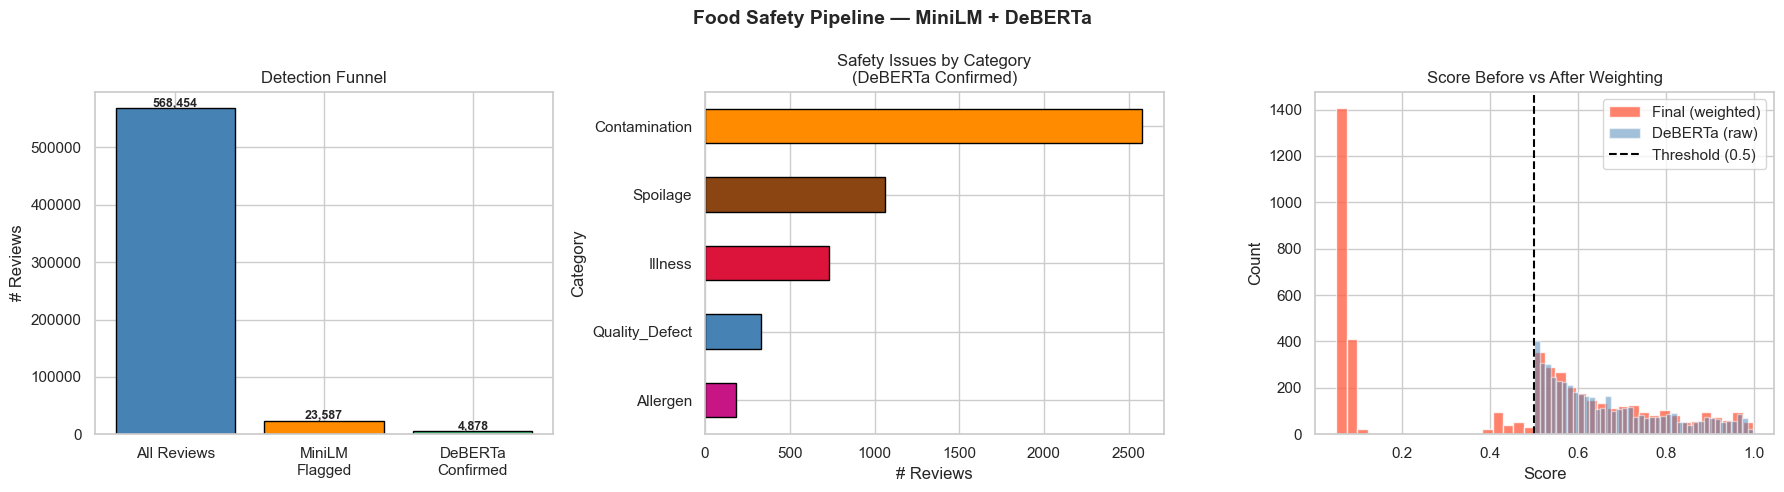

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Food Safety Pipeline — MiniLM + DeBERTa', fontsize=14, fontweight='bold')

# Panel 1: Pipeline funnel
stage_labels = ['All Reviews', 'MiniLM\nFlagged', 'DeBERTa\nConfirmed']
stage_counts = [n_total, n_minilm, n_confirmed]
bar_colors   = ['steelblue', 'darkorange', 'mediumseagreen']
bars = axes[0].bar(stage_labels, stage_counts, color=bar_colors, edgecolor='black')
axes[0].set_title('Detection Funnel')
axes[0].set_ylabel('# Reviews')
for bar, val in zip(bars, stage_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + n_total * 0.005,
                 f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# Panel 2: Category breakdown
cat_counts   = confirmed[confirmed['Category'] != 'Safe']['Category'].value_counts()
cat_colors   = {
    'Illness': 'crimson', 'Contamination': 'darkorange',
    'Allergen': 'mediumvioletred', 'Spoilage': 'saddlebrown', 'Quality_Defect': 'steelblue',
}
cat_counts.plot(kind='barh', ax=axes[1],
                color=[cat_colors.get(c, 'gray') for c in cat_counts.index], edgecolor='black')
axes[1].set_title('Safety Issues by Category\n(DeBERTa Confirmed)')
axes[1].set_xlabel('# Reviews')
axes[1].invert_yaxis()

# Panel 3: FinalSafetyScore distribution (after weighting)
axes[2].hist(confirmed['FinalSafetyScore'], bins=40, color='tomato', alpha=0.8, label='Final (weighted)')
axes[2].hist(confirmed['DebertaScore'],     bins=40, color='steelblue', alpha=0.5, label='DeBERTa (raw)')
axes[2].axvline(DEBERTA_THRESHOLD, color='black', linestyle='--', linewidth=1.5,
                label=f'Threshold ({DEBERTA_THRESHOLD})')
axes[2].set_title('Score Before vs After Weighting')
axes[2].set_xlabel('Score')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.show()


In [109]:
OUTPUT_DIR = 'outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
OUT_FILE = os.path.join(OUTPUT_DIR, 'food_safety_results.xlsx')

def clean_for_excel(series):
    illegal = set(chr(i) for i in list(range(0, 9)) + [11, 12] + list(range(14, 32)))
    return series.astype(str).apply(lambda s: ''.join(c for c in s if c not in illegal))

MAX_LEN = 32767

with pd.ExcelWriter(OUT_FILE, engine='openpyxl') as writer:

    # Sheet 1: All MiniLM-flagged reviews
    sheet1 = candidates[['Score', 'SemanticScore', 'Category', 'Text']].copy()
    sheet1['Text'] = clean_for_excel(sheet1['Text'].str[:MAX_LEN])
    sheet1.to_excel(writer, sheet_name='MiniLM_Flagged', index=False)

    # Sheet 2: DeBERTa-confirmed reviews with weighting scores
    export_cols = ['Score', 'SemanticScore', 'DebertaScore', 'Category', 'Severity',
                   'Weight', 'FinalSafetyScore', 'Text']
    sheet2 = confirmed[[c for c in export_cols if c in confirmed.columns]].copy()
    sheet2 = sheet2.sort_values('FinalSafetyScore', ascending=False)
    sheet2['Text'] = clean_for_excel(sheet2['Text'].str[:MAX_LEN])
    sheet2.to_excel(writer, sheet_name='DeBERTa_Confirmed', index=False)

print(f'Exported to: {os.path.abspath(OUT_FILE)}')
print(f'  Sheet "MiniLM_Flagged"    : {len(sheet1):,} rows')
print(f'  Sheet "DeBERTa_Confirmed" : {len(sheet2):,} rows')


Exported to: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\food_safety_results.xlsx
  Sheet "MiniLM_Flagged"    : 23,587 rows
  Sheet "DeBERTa_Confirmed" : 4,878 rows


---
## 6. Product-Level Safety Assessment

Group confirmed hazard reviews by `ProductId` and score each product using **Bayesian Average** smoothing.

$$\text{BayesianScore} = \frac{v \times R + m \times C}{v + m}$$

| Variable | Meaning |
|:---:|---|
| $v$ | Total reviews for this product |
| $R$ | Raw hazard score = Σ severity weights / $v$ |
| $m$ | Prior weight = Q95 of review count distribution |
| $C$ | Global mean hazard score across all products (safe products contribute 0) |

Products with few reviews are pulled toward the dataset mean $C$.
As $v$ grows, `BayesianScore` converges to the product's own raw score $R$.

| BayesianScore | Risk Level |
|:---:|:---|
| ≥ 0.30  OR  (High severity + HazardRate ≥ 10%) | 🔴 High Risk |
| ≥ 0.05 | 🟡 Medium Risk |
| < 0.05 | 🟢 Low Risk |


In [110]:
from pymongo import UpdateMany

# Fetch ProductId for confirmed hazard reviews
confirmed_ids = confirmed['_id'].tolist()
prod_id_map   = {
    d['_id']: d.get('ProductId', 'UNKNOWN')
    for d in COL.find({'_id': {'$in': confirmed_ids}}, {'ProductId': 1})
}
confirmed = confirmed.copy()
confirmed['ProductId'] = confirmed['_id'].map(prod_id_map).fillna('UNKNOWN')

# Total reviews per product (denominator)
total_per_product = {
    d['_id']: d['TotalReviews']
    for d in COL.aggregate([{'$group': {'_id': '$ProductId', 'TotalReviews': {'$sum': 1}}}])
}

SEVERITY_WEIGHT = {'High': 3, 'Medium': 2, 'Low': 1, 'None': 0, 'Unknown': 0}
hazard_rows     = confirmed[confirmed['Category'] != 'Safe'].copy()

rows = []
for product_id, group in hazard_rows.groupby('ProductId'):
    total     = total_per_product.get(product_id, len(group))
    hz_count  = len(group)
    raw_score = sum(SEVERITY_WEIGHT.get(s, 0) for s in group['Severity']) / total

    rows.append({
        'ProductId':        product_id,
        'TotalReviews':     total,
        'HazardCount':      hz_count,
        'HazardRate':       round(hz_count / total, 4),
        '_raw':             round(raw_score, 6),
        'DominantCategory': group['Category'].value_counts().index[0],
        'isSafe':           False,
    })

product_summary = pd.DataFrame(rows)

# Bayesian smoothing:  BayesianScore = (v×R + m×C) / (v+m)
n_total_prods = len(total_per_product)
C = product_summary['_raw'].sum() / n_total_prods           # global mean (safe prods = 0)
m = float(np.percentile(list(total_per_product.values()), 95))  # prior weight (Q95)

product_summary['BayesianScore'] = (
    (product_summary['TotalReviews'] * product_summary['_raw'] + m * C) /
    (product_summary['TotalReviews'] + m)
).round(6)

product_summary.drop(columns=['_raw'], inplace=True)

# Risk level based on BayesianScore thresholds
product_summary['RiskLevel'] = product_summary['BayesianScore'].apply(
    lambda s: 'High Risk' if s >= 0.20 else ('Medium Risk' if s >= 0.10 else 'Low Risk')
)

print(f'Unsafe products : {len(product_summary):,}')
print(f'  C = {C:.6f}  |  m = {m:.0f} reviews (Q95)')
print(f'\nRisk breakdown:')
print(product_summary['RiskLevel'].value_counts().to_string())
print(f'\nTop 10 by BayesianScore:')
cols = ['ProductId', 'TotalReviews', 'HazardCount', 'HazardRate', 'BayesianScore', 'RiskLevel']
print(product_summary.sort_values('BayesianScore', ascending=False).head(10)[cols].to_string(index=False))


Unsafe products : 3,497
  C = 0.023654  |  m = 26 reviews (Q95)

Risk breakdown:
RiskLevel
Low Risk       2326
Medium Risk    1130
High Risk        41

Top 10 by BayesianScore:
 ProductId  TotalReviews  HazardCount  HazardRate  BayesianScore RiskLevel
B0002YW26E            84           18      0.2143       0.496500 High Risk
B000HJ7AIY           171           27      0.1579       0.414289 High Risk
B0009XPD64            34            6      0.1765       0.310250 High Risk
B003Z4F56C            28            5      0.1786       0.289167 High Risk
B00014E3LM            10            3      0.3000       0.267083 High Risk
B0015DA1HI            13            3      0.2308       0.246539 High Risk
B00002N8SM            38            5      0.1316       0.243984 High Risk
B000Y2EJHY             2            2      1.0000       0.236250 High Risk
B003SMTZ58             2            2      1.0000       0.236250 High Risk
B0000CNU07             2            2      1.0000       0.236250 High Ris

In [111]:
PRODUCT_OUT_FILE = os.path.join('outputs', 'product_safety_summary.xlsx')
os.makedirs('outputs', exist_ok=True)

# Build all-products DataFrame (safe products fill to defaults)
all_prods = pd.DataFrame([
    {'ProductId': pid, 'TotalReviews': cnt}
    for pid, cnt in total_per_product.items()
]).merge(
    product_summary[['ProductId', 'HazardCount', 'HazardRate', 'BayesianScore',
                     'DominantCategory', 'RiskLevel', 'isSafe']],
    on='ProductId', how='left'
)
all_prods['isSafe']           = all_prods['isSafe'].fillna(True)
all_prods['HazardCount']      = all_prods['HazardCount'].fillna(0).astype(int)
all_prods['BayesianScore']    = all_prods['BayesianScore'].fillna(0.0)
all_prods['HazardRate']       = all_prods['HazardRate'].fillna(0.0)
all_prods['DominantCategory'] = all_prods['DominantCategory'].fillna('-')
all_prods['RiskLevel']        = all_prods['RiskLevel'].fillna('Safe')

EXPORT_COLS = ['ProductId', 'TotalReviews', 'HazardCount', 'HazardRate',
               'BayesianScore', 'DominantCategory', 'RiskLevel']

with pd.ExcelWriter(PRODUCT_OUT_FILE, engine='openpyxl') as writer:
    # Sheet 1: unsafe products only, sorted by BayesianScore
    unsafe_out = product_summary.sort_values('BayesianScore', ascending=False)[EXPORT_COLS].copy()
    unsafe_out.to_excel(writer, sheet_name='Unsafe_Products', index=False)

    # Sheet 2: all products (unsafe first, then safe)
    all_out = (
        all_prods
        .sort_values(['isSafe', 'BayesianScore'], ascending=[True, False])
        [['ProductId', 'TotalReviews', 'isSafe'] + EXPORT_COLS[1:]]
        .copy()
    )
    all_out.to_excel(writer, sheet_name='All_Products', index=False)

print(f'Exported: {os.path.abspath(PRODUCT_OUT_FILE)}')
print(f'  Unsafe_Products : {len(unsafe_out):,} rows')
print(f'  All_Products    : {len(all_out):,} rows')


C:\Users\Hanz\AppData\Local\Temp\ipykernel_3888\3537755913.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  all_prods['isSafe']           = all_prods['isSafe'].fillna(True)


Exported: c:\Users\Hanz\Documents\NTUST Hans\Semester 1\Big Data\projects\project1_nlp_amazon_food_review\outputs\product_safety_summary.xlsx
  Unsafe_Products : 3,497 rows
  All_Products    : 74,258 rows


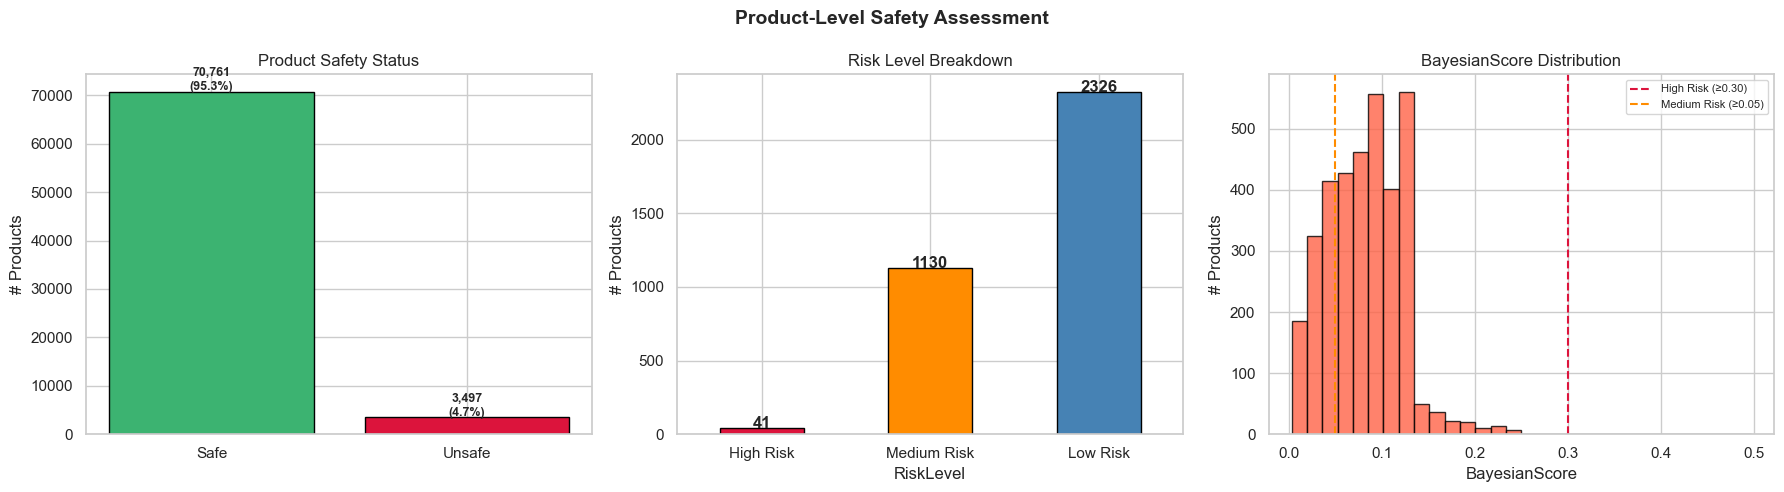

Total products  : 74,258
Safe products   : 70,761  (95.3%)
Unsafe products : 3,497  (4.7%)


In [112]:
n_total_prods  = len(total_per_product)
n_unsafe_prods = len(product_summary)
n_safe_prods   = n_total_prods - n_unsafe_prods

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Product-Level Safety Assessment', fontsize=14, fontweight='bold')

# Panel 1: Safe vs Unsafe
bars = axes[0].bar(['Safe', 'Unsafe'], [n_safe_prods, n_unsafe_prods],
                   color=['mediumseagreen', 'crimson'], edgecolor='black')
axes[0].set_title('Product Safety Status')
axes[0].set_ylabel('# Products')
for bar, val in zip(bars, [n_safe_prods, n_unsafe_prods]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + n_total_prods * 0.005,
                 f'{val:,}\n({val/n_total_prods:.1%})',
                 ha='center', fontweight='bold', fontsize=9)

# Panel 2: Risk level breakdown
risk_order  = ['High Risk', 'Medium Risk', 'Low Risk']
risk_counts = product_summary['RiskLevel'].value_counts().reindex(risk_order, fill_value=0)
risk_counts.plot(kind='bar', ax=axes[1],
                 color=['crimson', 'darkorange', 'steelblue'], edgecolor='black', rot=0)
axes[1].set_title('Risk Level Breakdown')
axes[1].set_ylabel('# Products')
for bar, val in zip(axes[1].patches, risk_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(val), ha='center', fontweight='bold')

# Panel 3: BayesianScore distribution
axes[2].hist(product_summary['BayesianScore'], bins=30,
             color='tomato', edgecolor='black', alpha=0.8)
axes[2].axvline(0.30, color='crimson',    linestyle='--', linewidth=1.5, label='High Risk (≥0.30)')
axes[2].axvline(0.05, color='darkorange', linestyle='--', linewidth=1.5, label='Medium Risk (≥0.05)')
axes[2].set_title('BayesianScore Distribution')
axes[2].set_xlabel('BayesianScore')
axes[2].set_ylabel('# Products')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'Total products  : {n_total_prods:,}')
print(f'Safe products   : {n_safe_prods:,}  ({n_safe_prods/n_total_prods:.1%})')
print(f'Unsafe products : {n_unsafe_prods:,}  ({n_unsafe_prods/n_total_prods:.1%})')
